# Digital Fabrication Process Impact Calculator

**Project:** Biobased Construction Impact Calculator (module 2)
**Database:** `ecoinvent-3.12-cutoff`
**Date:** 2026

## Purpose

This notebook computes recipe-independent unit environmental burdens for the two
generic inputs behind any digital fabrication process — machine wear and electricity
use — then exposes a single parametrized function, `estimate_process_impact()`, that
converts those unit burdens into a per-kg-output impact for **any** fabrication
process, given just five numbers: machine weight, power draw, process time, machine
lifetime, and output mass.

**Machine wear** is deliberately modeled with a single generic ecoinvent dataset
(`market for industrial machine, heavy, unspecified`) rather than a per-process
machine lookup — the goal isn't to model each machine's exact bill of materials, but
to give a reasonable order-of-magnitude equipment-depreciation burden that scales with
how heavy the machine is and how much of its lifetime a given job consumes.

**Electricity**, by contrast, is resolved per country across Europe — grid mix varies
enormously, and exposing `location` as a parameter to `estimate_process_impact()` lets
downstream users see how much a process's footprint shifts just by rerunning it with a
different country's grid, without touching anything else.

Section 5 demonstrates the function against four real digital fabrication processes
(3D printing, CNC knitting, coreless filament winding, CNC milling), each at small-
and large-scale, using representative machine/power/output-efficiency figures, and
compares two contrasting European grids to show the location effect.

This notebook reuses the same Brightway project as `01_materials_module.ipynb`
(`biobased_construction_impact_calculator`), so ecoinvent does not need re-importing.

---

## 1. bw project/database setup

### 1.1 Setup and version pinning

In [1]:
import bw2data as bd
import bw2io as bi
import bw2calc as bc
import pandas as pd
import importlib.metadata

# ── Version pinning ───────────────────────────────────────────────────────────
for pkg in ["bw2data", "bw2io", "bw2calc"]:
    print(f"  {pkg}: {importlib.metadata.version(pkg)}")
print()

# ── Project and database naming ───────────────────────────────────────────────
# Same project as 01_materials_module.ipynb — ecoinvent is already imported there,
# so this notebook connects to it rather than re-importing (15–30 min, once only).
PROJECT_NAME     = "biobased_construction_impact_calculator"
EI_VERSION       = "3.12"
EI_MODEL         = "cutoff"
EI_DB_NAME       = f"ecoinvent-{EI_VERSION}-{EI_MODEL}"       # "ecoinvent-3.12-cutoff"
BIOSPHERE_NAME   = f"ecoinvent-{EI_VERSION}-biosphere"        # "ecoinvent-3.12-biosphere"

# ── LCIA method naming ────────────────────────────────────────────────────────
# Same namespacing as 01_materials_module.ipynb: (namespace, family, category, indicator).
METHOD_NAMESPACE = f"ecoinvent-{EI_VERSION}"
METHOD_FAMILY    = "EF v3.1"

  bw2data: 4.4.2
  bw2io: 0.9.6
  bw2calc: 2.0.1



### 1.2 Connect to project

`bd.projects.set_current()` just switches to the project if it already exists — it
does not re-trigger the ecoinvent import. The import branch below is a safety net
only, in case this notebook is ever run somewhere `01_materials_module.ipynb` hasn't
been run first.

In [2]:
import os

# ── Connect to (or create) the project ────────────────────────────────────────
bd.projects.set_current(PROJECT_NAME)
print(f"Active project: {bd.projects.current}")

# ── Import ecoinvent, if not already present ──────────────────────────────────
if EI_DB_NAME in bd.databases:
    print(f"'{EI_DB_NAME}' already imported ({len(bd.Database(EI_DB_NAME))} datasets) — skipping.")
else:
    ei_username = os.environ.get("ECOINVENT_USERNAME")
    ei_password = os.environ.get("ECOINVENT_PASSWORD")

    bi.import_ecoinvent_release(
        version=EI_VERSION,
        system_model=EI_MODEL,
        username=ei_username,
        password=ei_password,
    )
    print(f"Imported '{EI_DB_NAME}': {len(bd.Database(EI_DB_NAME))} datasets")

ei = bd.Database(EI_DB_NAME)

Active project: biobased_construction_impact_calculator
'ecoinvent-3.12-cutoff' already imported (26533 datasets) — skipping.


### 1.3 EF v3.1 impact categories and units

Unlike `01_materials_module.ipynb`'s `EF_UNITS`, which is a hand-maintained dict, this
pulls the unit for each category straight from the method's own metadata
(`bd.Method(m).metadata["unit"]`). One less thing to keep in sync between notebooks,
and it stays correct even if a future ecoinvent version adds or renames categories.

In [3]:
# ── EF v3.1 methods, namespaced under this ecoinvent version ─────────────────
EF_METHODS = [
    m for m in bd.methods
    if m[0] == METHOD_NAMESPACE and m[1] == METHOD_FAMILY
]
print(f"Found {len(EF_METHODS)} EF v3.1 method tuples")

# ── Units lookup, pulled from method metadata rather than hardcoded ──────────
EF_UNITS = {m[2]: bd.Method(m).metadata.get("unit", "—") for m in EF_METHODS}
pd.Series(EF_UNITS, name="unit").rename_axis("category").to_frame()

Found 25 EF v3.1 method tuples


,unit
category,
acidification,mol H+-Eq
climate change,kg CO2-Eq
climate change: biogenic,kg CO2-Eq
climate change: fossil,kg CO2-Eq
climate change: land use and land use change,kg CO2-Eq
ecotoxicity: freshwater,CTUe
"ecotoxicity: freshwater, inorganics",CTUe
"ecotoxicity: freshwater, organics",CTUe
energy resources: non-renewable,"MJ, net calorific value"


---

## 2. Resolve ecoinvent activities

### 2.1 Helper functions for ecoinvent lookup

Same pattern as `find_ei()` / `search_ei()` in `01_materials_module.ipynb`.

In [4]:
def find_ei(name, location, ref_product=None):
    """Look up a single ecoinvent activity by exact name and location."""
    results = [
        a for a in ei
        if a["name"] == name
        and a["location"] == location
        and (ref_product is None or a.get("reference product") == ref_product)
    ]
    if len(results) == 0:
        raise ValueError(f"Ecoinvent dataset not found: '{name}' | {location}")
    if len(results) > 1:
        print(f"  Warning: multiple matches for '{name}' | {location} — using first")
    return results[0]


def search_ei(keyword, max_results=20):
    """
    Broad keyword search across ecoinvent. Used to verify dataset names and the
    location codes available for them before hard-coding a list.
    """
    keyword_lower = keyword.lower()
    results = [a for a in ei if keyword_lower in a["name"].lower()]
    print(f"Found {len(results)} dataset(s) matching '{keyword}':")
    for a in results[:max_results]:
        print(f"  name: {a['name']:<55s} location: {a['location']:<8s} unit: {a.get('unit')}")
    return results

### 2.2 Machine wear — single generic dataset

One generic dataset stands in for "whatever machine this process runs on":
`market for industrial machine, heavy, unspecified`, global (`GLO`) market. This is a
deliberate simplification (see notebook intro) — it gives an order-of-magnitude
capital-equipment burden that scales with declared machine weight and time-in-use,
not a bespoke bill of materials per machine type.

Run `search_ei("industrial machine")` first if this exact name doesn't resolve in
your ecoinvent version.

In [6]:
MACHINE_NAME     = "market for industrial machine, heavy, unspecified"
MACHINE_LOCATION = "RER"

machine_act = find_ei(MACHINE_NAME, MACHINE_LOCATION)
print(f"Resolved: '{machine_act['name']}' | {machine_act['location']} | unit: {machine_act.get('unit')}")

Resolved: 'market for industrial machine, heavy, unspecified' | RER | unit: kilogram


### 2.3 Machine unit conversion check (→ kg)

Same caution as `01_materials_module.ipynb` Section 3.1: ecoinvent doesn't always use
kilogram as the reference unit, and the machine-wear formula assumes `kg_machine` is
directly comparable to the resolved activity's functional unit. If the unit isn't
already `kilogram`, this falls back to the `wet mass` property (kg per reference unit)
to convert — a no-op (factor ≈ 1) for already-kg activities.

In [7]:
def get_production_properties(act):
    """Return the properties dict from an activity's production exchange, or {} if none."""
    for exc in act.production():
        return exc.get("properties", {})
    return {}


def get_kg_conversion_factor(act):
    """
    Returns (factor, note) to convert a 1-unit LCA score into a per-kg score.
    factor = kg per 1 reference unit of `act`.
    """
    unit = (act.get("unit") or "").lower()

    if unit == "kilogram":
        return 1.0, "kg — no conversion needed"

    props = get_production_properties(act)
    wet_mass = props.get("wet mass", {}).get("amount")

    if wet_mass is None:
        raise ValueError(
            f"'{act['name']}' has unit '{unit}' (not kg) and no 'wet mass' property "
            f"to convert with — resolve this manually before proceeding."
        )
    return wet_mass, f"non-kg unit ('{unit}') — converted via 'wet mass' property"


machine_kg_factor, note = get_kg_conversion_factor(machine_act)
print(f"Machine kg-conversion factor: {machine_kg_factor}  ({note})")

Machine kg-conversion factor: 1.0  (kg — no conversion needed)


### 2.4 Electricity — resolve across all European countries

Grid mix varies a lot across Europe, so rather than fixing one location, this resolves
the electricity market for every European country ecoinvent has a dataset for. That
list is then used in Section 3 to compute a unit burden *per country*, so
`estimate_process_impact()` can take `electricity_location` as a parameter.

**Assumption to check against your own use case:** this uses `market for electricity,
medium voltage` (typical for industrial/workshop equipment) rather than `low voltage`
(typical for household-scale appliances). If your fabrication processes are closer to
desktop-scale, switch `ELECTRICITY_ACTIVITY_NAME` below to `"market for electricity,
low voltage"` — everything downstream is unaffected by which you pick, since both
have the same country/location coverage pattern in ecoinvent.

Run `search_ei("market for electricity, medium voltage")` first to confirm the exact
name and see which location codes exist in your ecoinvent version before trusting the
list below — ecoinvent's electricity market coverage has changed between versions.

In [8]:
ELECTRICITY_ACTIVITY_NAME = "market for electricity, medium voltage"

# European country codes to attempt. Not every one will necessarily resolve —
# ecoinvent's country-level electricity market coverage varies by version/region
# (e.g. some smaller countries are only covered via a regional aggregate).
EUROPEAN_LOCATIONS = [
    "AT", "BE", "BG", "HR", "CY", "CZ", "DK", "EE", "FI", "FR", "DE", "GR",
    "HU", "IE", "IT", "LV", "LT", "LU", "MT", "NL", "PL", "PT", "RO", "SK",
    "SI", "ES", "SE", "GB", "CH", "NO",
]

electricity_activities = {}
missing_locations = []

for loc in EUROPEAN_LOCATIONS:
    try:
        electricity_activities[loc] = find_ei(ELECTRICITY_ACTIVITY_NAME, loc)
    except ValueError:
        missing_locations.append(loc)

print(f"Resolved electricity market for {len(electricity_activities)} / {len(EUROPEAN_LOCATIONS)} countries.")
if missing_locations:
    print(f"⚠ No dataset found for: {', '.join(missing_locations)}")
    print("  Run search_ei(ELECTRICITY_ACTIVITY_NAME) to check what location codes ecoinvent actually uses —")
    print("  some countries may only be covered via a regional/aggregate market in your ecoinvent version.")

Resolved electricity market for 30 / 30 countries.


---

## 3. Unit burdens

### 3.1 Unit burden per kg of machine

LCA on the machine activity, all EF v3.1 categories, 1 reference-unit functional
unit, normalized to a true 1 kg basis via the conversion factor from Section 2.3.

In [9]:
def compute_unit_burdens(activity, ef_methods, kg_conversion_factor=1.0):
    """LCA score for 1 kg of `activity`, across every method in `ef_methods`."""
    scores = {}
    for method in ef_methods:
        category = method[2]
        lca = bc.LCA({activity: 1}, method)
        lca.lci()
        lca.lcia()
        scores[category] = lca.score / kg_conversion_factor
    return pd.Series(scores, name="score").rename_axis("category")


machine_unit_burden = compute_unit_burdens(machine_act, EF_METHODS, kg_conversion_factor=machine_kg_factor)
print(f"Computed machine-wear unit burden across {len(machine_unit_burden)} categories.")
machine_unit_burden.head()

Computed machine-wear unit burden across 25 categories.


category
acidification                                   0.017537
climate change                                  2.531240
climate change: biogenic                        0.002060
climate change: fossil                          2.524260
climate change: land use and land use change    0.004920
Name: score, dtype: float64

### 3.2 Unit burden per kWh of electricity, all resolved European locations

Electricity market activities are already on a kWh basis in ecoinvent (no conversion
factor needed) — a quick unit check below confirms that rather than assuming it.

In [10]:
# ── Sanity check: electricity activities are declared in kWh ─────────────────
non_kwh = {loc: act.get("unit") for loc, act in electricity_activities.items() if act.get("unit") != "kilowatt hour"}
if non_kwh:
    print(f"⚠ {len(non_kwh)} location(s) not declared in kWh — check before trusting results: {non_kwh}")
else:
    print("All resolved electricity activities are declared in kWh — no conversion needed.")

# ── Unit burden per kWh, per country ──────────────────────────────────────────
electricity_unit_burdens = {}
for loc, act in electricity_activities.items():
    print(f"Computing unit burden for electricity | {loc} ...")
    electricity_unit_burdens[loc] = compute_unit_burdens(act, EF_METHODS, kg_conversion_factor=1.0)

df_electricity_unit_burdens = (
    pd.DataFrame(electricity_unit_burdens)   # categories as rows, locations as columns
    .rename_axis("category")
    .rename_axis("location", axis="columns")
)
df_electricity_unit_burdens.head()

All resolved electricity activities are declared in kWh — no conversion needed.
Computing unit burden for electricity | AT ...
Computing unit burden for electricity | BE ...
Computing unit burden for electricity | BG ...
Computing unit burden for electricity | HR ...
Computing unit burden for electricity | CY ...
Computing unit burden for electricity | CZ ...
Computing unit burden for electricity | DK ...
Computing unit burden for electricity | EE ...
Computing unit burden for electricity | FI ...
Computing unit burden for electricity | FR ...
Computing unit burden for electricity | DE ...
Computing unit burden for electricity | GR ...
Computing unit burden for electricity | HU ...
Computing unit burden for electricity | IE ...
Computing unit burden for electricity | IT ...
Computing unit burden for electricity | LV ...
Computing unit burden for electricity | LT ...
Computing unit burden for electricity | LU ...
Computing unit burden for electricity | MT ...
Computing unit burden for e

location,AT,BE,BG,HR,CY,CZ,DK,EE,FI,FR,...,PL,PT,RO,SK,SI,ES,SE,GB,CH,NO
category,,,,,,,,,,,,,,,,,,,,,
acidification,0.000852,0.000397,0.004107,0.005197,0.009254,0.002979,0.000809,0.004049,0.000644,0.000462,...,0.006659,0.000934,0.002387,0.002673,0.005563,0.001042,0.000171,0.000708,0.000104,0.000114
climate change,0.274654,0.204593,0.588636,0.461567,1.099341,0.681318,0.172710,0.527095,0.146098,0.121150,...,0.965371,0.260307,0.356539,0.433252,0.365628,0.262642,0.030647,0.272172,0.021927,0.029514
climate change: biogenic,0.000692,0.000368,0.000137,0.000691,0.000183,0.000410,0.000570,0.000363,0.000463,0.000212,...,0.000330,0.000758,0.000077,0.000446,0.000433,0.000403,0.000539,0.000658,0.000214,0.000395
climate change: fossil,0.273651,0.203543,0.588430,0.460720,1.099089,0.680022,0.171295,0.525351,0.143217,0.120804,...,0.964854,0.254609,0.356406,0.431235,0.365053,0.260061,0.026685,0.271143,0.021700,0.028928
climate change: land use and land use change,0.000311,0.000683,0.000069,0.000157,0.000069,0.000886,0.000845,0.001381,0.002419,0.000134,...,0.000187,0.004940,0.000056,0.001571,0.000142,0.002179,0.003422,0.000372,0.000013,0.000191


### 3.3 Assemble and export unit burdens

Long-format export, one row per (component, location, category) — `location` is blank
for machine wear, since that's a single generic dataset rather than a per-country one.

In [12]:
OUTPUT_DIR = "../data/processed"  # adjust to match your repo structure

# ── Machine wear, long format ─────────────────────────────────────────────────
df_machine_long = (
    machine_unit_burden
    .rename("score")
    .reset_index()
)
df_machine_long.insert(0, "component", "machine wear")
df_machine_long.insert(1, "location", pd.NA)

# ── Electricity, long format ──────────────────────────────────────────────────
df_electricity_long = (
    df_electricity_unit_burdens
    .reset_index()
    .melt(id_vars="category", var_name="location", value_name="score")
)
df_electricity_long.insert(0, "component", "energy use")
df_electricity_long = df_electricity_long[["component", "location", "category", "score"]]

# ── Combine, attach units, export ─────────────────────────────────────────────
df_process_unit_burdens = pd.concat([df_machine_long, df_electricity_long], ignore_index=True)
df_process_unit_burdens["unit"] = df_process_unit_burdens["category"].map(EF_UNITS)

df_process_unit_burdens.to_csv(f"{OUTPUT_DIR}/process_unit_burdens.csv", index=False)
print(f"Exported {len(df_process_unit_burdens)} rows to {OUTPUT_DIR}/process_unit_burdens.csv")
df_process_unit_burdens.head()

Exported 775 rows to ../data/processed/process_unit_burdens.csv


,component,location,category,score,unit
0,machine wear,NaN,acidification,0.017537,mol H+-Eq
1,machine wear,NaN,climate change,2.531240,kg CO2-Eq
2,machine wear,NaN,climate change: biogenic,0.002060,kg CO2-Eq
3,machine wear,NaN,climate change: fossil,2.524260,kg CO2-Eq
4,machine wear,NaN,climate change: land use and land use change,0.004920,kg CO2-Eq


---

## 4. Parametrized process-impact function

### 4.1 `estimate_process_impact()`

Combines the two unit burdens from Section 3 with five job-specific parameters:

$$
\text{machine wear (kg-eq/kg output)} = kg_{machine} \times \frac{t_{process}}{t_{lifetime}} \times \frac{1}{kg_{output}}
$$

$$
\text{energy use (kWh/kg output)} = P_{machine} \times t_{process} \times \frac{1}{kg_{output}}
$$

Each is then multiplied through the corresponding unit-burden vector and summed,
category by category, to give the total per-kg-output impact for that job.
`electricity_location` selects which country's grid mix to apply — this is the one
parameter that isn't a property of the machine or the job itself, so results for the
same job can be recomputed instantly for a different country.

In [14]:
from dataclasses import dataclass, field

@dataclass
class ProcessImpactResult:
    total: pd.Series               # combined burden, all EF v3.1 categories
    machine_component: pd.Series   # machine-wear contribution only
    energy_component: pd.Series    # energy-use contribution only
    machine_wear_kg_per_kg_output: float
    energy_use_kwh_per_kg_output: float
    electricity_location: str


def estimate_process_impact(
    kg_machine: float,
    power_kW: float,
    process_time_hrs: float,
    machine_lifetime_hrs: float,
    kg_output: float,
    electricity_location: str,
    machine_unit_burden: pd.Series = machine_unit_burden,
    electricity_unit_burdens: pd.DataFrame = df_electricity_unit_burdens,
) -> ProcessImpactResult:
    """
    Estimate the per-kg-output environmental impact of a digital fabrication job,
    across all EF v3.1 categories.

    Parameters
    ----------
    kg_machine            : mass of the machine used (kg)
    power_kW              : machine's power draw while running (kW)
    process_time_hrs      : time to produce `kg_output` (hrs)
    machine_lifetime_hrs  : expected total operating lifetime of the machine (hrs)
    kg_output             : mass of product output from this job (kg)
    electricity_location  : ecoinvent country code, e.g. "NL" — must be a column
                             in `electricity_unit_burdens` (see Section 2.4/3.2 for
                             which countries resolved).
    """
    if kg_output <= 0:
        raise ValueError("kg_output must be > 0")
    if process_time_hrs <= 0:
        raise ValueError("process_time_hrs must be > 0")
    if machine_lifetime_hrs <= 0:
        raise ValueError("machine_lifetime_hrs must be > 0")
    if process_time_hrs > machine_lifetime_hrs:
        print("⚠ process_time_hrs exceeds machine_lifetime_hrs — this single job would "
              "consume more than one full machine lifetime; check your inputs.")
    if electricity_location not in electricity_unit_burdens.columns:
        available = ", ".join(sorted(electricity_unit_burdens.columns))
        raise ValueError(
            f"No electricity unit burden for location '{electricity_location}'. "
            f"Available: {available}"
        )

    machine_wear_kg_per_kg_output = kg_machine * (process_time_hrs / machine_lifetime_hrs) / kg_output
    energy_use_kwh_per_kg_output = power_kW * process_time_hrs / kg_output

    machine_component = machine_wear_kg_per_kg_output * machine_unit_burden
    energy_component = energy_use_kwh_per_kg_output * electricity_unit_burdens[electricity_location]

    total = machine_component.add(energy_component, fill_value=0.0)

    return ProcessImpactResult(
        total=total,
        machine_component=machine_component,
        energy_component=energy_component,
        machine_wear_kg_per_kg_output=machine_wear_kg_per_kg_output,
        energy_use_kwh_per_kg_output=energy_use_kwh_per_kg_output,
        electricity_location=electricity_location,
    )

---

## 5. Example usage — four digital fabrication processes

### 5.1 Process parameters

Representative small-scale and large-scale figures for four digital fabrication
processes (machine lifetime, machine weight, output efficiency, power draw). Swap
these for your own process-specific numbers as they firm up.

Each job is evaluated on a **1 kg output basis**, so `process_time_hrs` is derived
from `output_efficiency_kg_per_hr` as `1 / output_efficiency_kg_per_hr` — the time it
takes that process, at that scale, to produce 1 kg of output.

In [15]:
PROCESS_PARAMS = [
    # process,                     scale,    lifetime_hrs, weight_kg, efficiency_kg_per_hr, power_kW
    ("3D printing",                "small",  6000,   15,   0.05, 0.1),
    ("3D printing",                "large",  40000,  1200, 15,   2.0),
    ("CNC knitting",               "small",  10000,  210,  0.15, 0.4),
    ("CNC knitting",               "large",  50000,  2000, 1.5,  4.0),
    ("Coreless filament winding",  "small",  12000,  200,  1.0,  1.0),
    ("Coreless filament winding",  "large",  50000,  5000, 10.0, 25.0),
    ("CNC milling",                "small",  12000,  80,   0.3,  1.2),
    ("CNC milling",                "large",  70000,  5000, 10.0, 20.0),
]

df_process_params = pd.DataFrame(
    PROCESS_PARAMS,
    columns=["process", "scale", "machine_lifetime_hrs", "machine_weight_kg",
             "output_efficiency_kg_per_hr", "power_kW"],
)
df_process_params["process_time_hrs_per_kg"] = 1.0 / df_process_params["output_efficiency_kg_per_hr"]
df_process_params

,process,scale,machine_lifetime_hrs,machine_weight_kg,output_efficiency_kg_per_hr,power_kW,process_time_hrs_per_kg
0,3D printing,small,6000,15,0.05,0.1,20.000000
1,3D printing,large,40000,1200,15.00,2.0,0.066667
2,CNC knitting,small,10000,210,0.15,0.4,6.666667
3,CNC knitting,large,50000,2000,1.50,4.0,0.666667
4,Coreless filament winding,small,12000,200,1.00,1.0,1.000000
5,Coreless filament winding,large,50000,5000,10.00,25.0,0.100000
6,CNC milling,small,12000,80,0.30,1.2,3.333333
7,CNC milling,large,70000,5000,10.00,20.0,0.100000


### 5.2 Run the function across processes, scales, and two contrasting grids

`SE` (largely hydro/nuclear) and `PL` (more coal-heavy) are used here purely to
illustrate how much `electricity_location` alone can move the result — swap in
whichever countries are actually relevant to you.

In [16]:
DEMO_LOCATIONS = ["SE", "PL"]  # swap for whichever countries matter to your comparison
KG_OUTPUT = 1.0  # basis for every job below

results = []
for row in df_process_params.itertuples():
    for loc in DEMO_LOCATIONS:
        result = estimate_process_impact(
            kg_machine=row.machine_weight_kg,
            power_kW=row.power_kW,
            process_time_hrs=row.process_time_hrs_per_kg,
            machine_lifetime_hrs=row.machine_lifetime_hrs,
            kg_output=KG_OUTPUT,
            electricity_location=loc,
        )
        results.append({
            "process": row.process,
            "scale": row.scale,
            "electricity_location": loc,
            "climate_change_kgCO2eq_per_kg": result.total["climate change"],
            "machine_wear_share": result.machine_component["climate change"] / result.total["climate change"],
            "energy_use_share": result.energy_component["climate change"] / result.total["climate change"],
        })

df_results = pd.DataFrame(results)
df_results.sort_values(["process", "scale", "electricity_location"])

,process,scale,electricity_location,climate_change_kgCO2eq_per_kg,machine_wear_share,energy_use_share
3,3D printing,large,PL,0.133779,0.037842,0.962158
2,3D printing,large,SE,0.009149,0.553352,0.446648
1,3D printing,small,PL,2.057305,0.061518,0.938482
0,3D printing,small,SE,0.187856,0.673718,0.326282
7,CNC knitting,large,PL,2.641823,0.025550,0.974450
6,CNC knitting,large,SE,0.149225,0.452335,0.547665
5,CNC knitting,small,PL,2.928697,0.121000,0.879000
4,CNC knitting,small,SE,0.436099,0.812599,0.187401
15,CNC milling,large,PL,1.948823,0.009278,0.990722
14,CNC milling,large,SE,0.079374,0.227785,0.772215


### 5.3 Visualize — climate change impact by process, scale, and grid

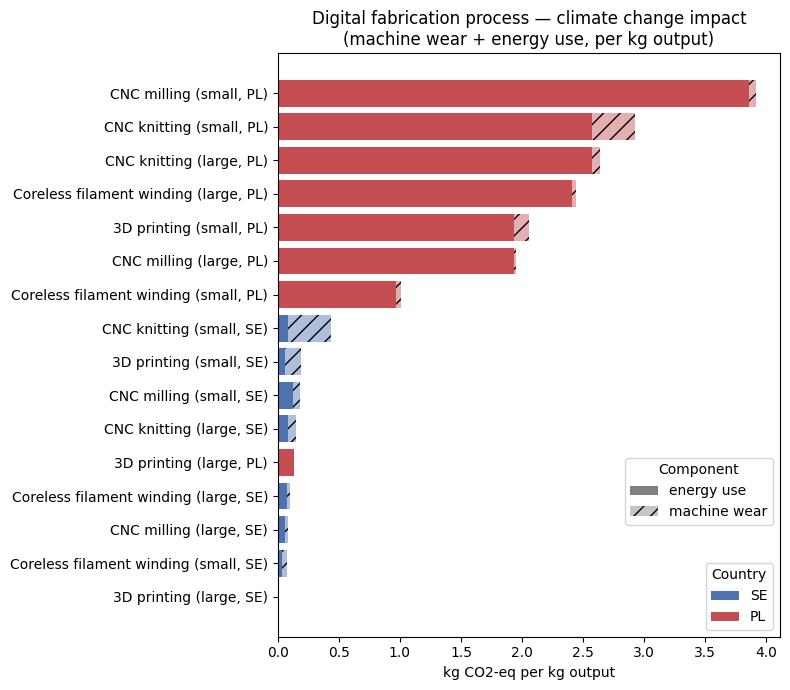

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COUNTRY_COLORS = {"SE": "#4C72B0", "PL": "#C44E52"}

# ── Recover absolute component values from the shares already in df_results ──
df_plot = df_results.copy()
df_plot["machine_wear_kgCO2eq_per_kg"] = df_plot["climate_change_kgCO2eq_per_kg"] * df_plot["machine_wear_share"]
df_plot["energy_use_kgCO2eq_per_kg"] = df_plot["climate_change_kgCO2eq_per_kg"] * df_plot["energy_use_share"]

df_plot["label"] = df_plot["process"] + " (" + df_plot["scale"] + ", " + df_plot["electricity_location"] + ")"
df_plot = df_plot.sort_values("climate_change_kgCO2eq_per_kg")

fig, ax = plt.subplots(figsize=(8, 7))
colors = df_plot["electricity_location"].map(COUNTRY_COLORS)

# ── Stack: energy use first (solid), machine wear on top (hatched) ───────────
ax.barh(df_plot["label"], df_plot["energy_use_kgCO2eq_per_kg"], color=colors)
ax.barh(
    df_plot["label"], df_plot["machine_wear_kgCO2eq_per_kg"],
    left=df_plot["energy_use_kgCO2eq_per_kg"],
    color=colors, alpha=0.45, hatch="//",
)

ax.set_xlabel("kg CO2-eq per kg output")
ax.set_title("Digital fabrication process — climate change impact\n(machine wear + energy use, per kg output)")

# ── Two-part legend: country (color) and component (fill style) ─────────────
country_handles = [Patch(facecolor=c, label=loc) for loc, c in COUNTRY_COLORS.items()]
component_handles = [
    Patch(facecolor="grey", alpha=1.0, label="energy use"),
    Patch(facecolor="grey", alpha=0.45, hatch="//", label="machine wear"),
]
legend1 = ax.legend(handles=country_handles, title="Country", loc="lower right")
ax.add_artist(legend1)
ax.legend(handles=component_handles, title="Component", loc="lower right", bbox_to_anchor=(1.0, 0.18))

plt.tight_layout()
plt.show()

### 5.4 Visualize — full impact profile, EF-normalized, by scale and grid

Rather than one impact category at a time, this shows *all* EF v3.1 headline
categories on one chart per (scale, location) combination, using EF v3.1
normalization factors (JRC reference package, 2010 global population basis) to make
categories with wildly different units comparable — each bar becomes "person-
equivalents of annual impact" rather than kg CO2-eq, mol H+-eq, etc.

The representative job for each scale is the **average** of the four processes'
raw parameters (machine weight, power, lifetime, output efficiency) from Section 5.1,
run for a fixed **1 hour of machining time** — `kg_output` follows from that hour at
the averaged output efficiency.

Machine wear vs. energy use is still shown as a stacked split within each bar; SE and
PL are shown as separate panels since a full 16-category profile is too dense to
usefully overlay by color.

In [ ]:
# ── EF v3.1 official normalization factors ────────────────────────────────────
# Source: JRC EF 3.1 reference package (2010 global population = 6,895,889,018),
# via https://nexus.openlca.org/ws/files/36224. Units: [indicator unit]/person/year.
NORMALIZATION_FACTORS = {
    "acidification":                        55.56954123060,
    "climate change":                        7553.083162851,
    "ecotoxicity, freshwater":               56716.58633706,
    "particulate matter":                    5.953668211255e-4,
    "eutrophication, freshwater":            1.606852128288,
    "eutrophication, marine":                19.54518155192,
    "eutrophication, terrestrial":           176.7549997889,
    "human toxicity, cancer":                1.725289765387e-5,
    "human toxicity, non-cancer":            1.287357350081e-4,
    "ionising radiation":                    4220.163390150,
    "land use":                              819498.1829230,
    "ozone depletion":                       0.05234838338402,
    "photochemical ozone formation":         40.85919773478,
    "resource use, fossils":                 65004.25966402,
    "resource use, minerals and metals":     0.06362261523695,
    "water use":                             11468.70864076,
}

# ── Best-effort matching from your ecoinvent/bw2 category strings ────────────
# Ecoinvent's exact category label text varies slightly by version — this is a
# substring match, not a guarantee. ALWAYS check the printed match table below
# before trusting the chart.
CATEGORY_ALIASES = {
    "acidification":                    ["acidification"],
    "climate change":                   ["climate change"],
    "ecotoxicity, freshwater":          ["ecotoxicity: freshwater", "ecotoxicity, freshwater", "freshwater ecotoxicity"],
    "particulate matter":               ["particulate matter"],
    "eutrophication, freshwater":       ["eutrophication: freshwater", "eutrophication, freshwater"],
    "eutrophication, marine":           ["eutrophication: marine", "eutrophication, marine"],
    "eutrophication, terrestrial":      ["eutrophication: terrestrial", "eutrophication, terrestrial"],
    "human toxicity, cancer":           ["human toxicity: carcinogenic", "human toxicity, cancer"],
    "human toxicity, non-cancer":       ["human toxicity: non-carcinogenic", "human toxicity, non-cancer"],
    "ionising radiation":               ["ionising radiation", "ionizing radiation"],
    "land use":                         ["land use"],
    "ozone depletion":                  ["ozone depletion"],
    "photochemical ozone formation":    ["photochemical oxidant formation", "photochemical ozone formation"],
    "resource use, fossils":            ["energy resources", "resource use: fossils", "resource use, fossils"],
    "resource use, minerals and metals": ["material resources", "resource use: minerals", "resource use, minerals"],
    "water use":                        ["water use"],
}
# Categories to explicitly exclude from the "climate change" match, since they're
# sub-splits without their own official NF, not the headline total.
CLIMATE_CHANGE_EXCLUDE = ["biogenic", "fossil", "land use and land use change", "luluc"]


def match_normalization_category(category_name):
    """Return the canonical NF key for a bw2 category string, or None if unmatched."""
    name_lower = category_name.lower()
    if "climate change" in name_lower and any(x in name_lower for x in CLIMATE_CHANGE_EXCLUDE):
        return None  # sub-split, not the headline total — skip
    for canonical, aliases in CATEGORY_ALIASES.items():
        if any(alias in name_lower for alias in aliases):
            return canonical
    return None


# ── Print the match table so you can sanity-check before trusting the chart ──
all_categories = machine_unit_burden.index.tolist()
match_table = pd.DataFrame({
    "bw2_category": all_categories,
    "matched_to": [match_normalization_category(c) for c in all_categories],
})
unmatched = match_table[match_table["matched_to"].isna()]
if len(unmatched):
    print(f"⚠ {len(unmatched)} categories have no normalization match and will be excluded from the chart:")
    print(unmatched["bw2_category"].tolist())
match_table.dropna()

⚠ 3 categories have no normalization match and will be excluded from the chart:
['climate change: biogenic', 'climate change: fossil', 'climate change: land use and land use change']


,bw2_category,matched_to
0,acidification,acidification
1,climate change,climate change
5,ecotoxicity: freshwater,"ecotoxicity, freshwater"
6,"ecotoxicity: freshwater, inorganics","ecotoxicity, freshwater"
7,"ecotoxicity: freshwater, organics","ecotoxicity, freshwater"
8,energy resources: non-renewable,"resource use, fossils"
9,eutrophication: freshwater,"eutrophication, freshwater"
10,eutrophication: marine,"eutrophication, marine"
11,eutrophication: terrestrial,"eutrophication, terrestrial"
12,human toxicity: carcinogenic,"human toxicity, cancer"


In [37]:
# ── Resolve each canonical category to exactly ONE bw2 source category ───────
# (Multiple bw2 categories can share substrings — e.g. "climate change" and
# "climate change: total" — which would otherwise produce duplicate rows.)
all_categories = machine_unit_burden.index.tolist()

canonical_to_bw2 = {}       # canonical -> chosen bw2 category (first match wins)
ambiguous_matches = {}      # canonical -> list of ALL bw2 categories that matched

for category_name in all_categories:
    canonical = match_normalization_category(category_name)
    if canonical is None:
        continue
    if canonical not in canonical_to_bw2:
        canonical_to_bw2[canonical] = category_name
    ambiguous_matches.setdefault(canonical, []).append(category_name)

# ── Report anything ambiguous, and anything unmatched ─────────────────────────
duplicates = {k: v for k, v in ambiguous_matches.items() if len(v) > 1}
if duplicates:
    print("⚠ Ambiguous matches — only the FIRST bw2 category is used for each; check these:")
    for canonical, bw2_cats in duplicates.items():
        print(f"  '{canonical}' <- {bw2_cats}  (using: '{canonical_to_bw2[canonical]}')")
    print()

unmatched = [c for c in all_categories if match_normalization_category(c) is None]
if unmatched:
    print(f"⚠ {len(unmatched)} categories have no normalization match and will be excluded:")
    print(unmatched)

pd.Series(canonical_to_bw2, name="bw2_category").rename_axis("canonical_category").to_frame()

⚠ Ambiguous matches — only the FIRST bw2 category is used for each; check these:
  'ecotoxicity, freshwater' <- ['ecotoxicity: freshwater', 'ecotoxicity: freshwater, inorganics', 'ecotoxicity: freshwater, organics']  (using: 'ecotoxicity: freshwater')
  'human toxicity, cancer' <- ['human toxicity: carcinogenic', 'human toxicity: carcinogenic, inorganics', 'human toxicity: carcinogenic, organics']  (using: 'human toxicity: carcinogenic')
  'human toxicity, non-cancer' <- ['human toxicity: non-carcinogenic', 'human toxicity: non-carcinogenic, inorganics', 'human toxicity: non-carcinogenic, organics']  (using: 'human toxicity: non-carcinogenic')

⚠ 3 categories have no normalization match and will be excluded:
['climate change: biogenic', 'climate change: fossil', 'climate change: land use and land use change']


,bw2_category
canonical_category,
acidification,acidification
climate change,climate change
"ecotoxicity, freshwater",ecotoxicity: freshwater
"resource use, fossils",energy resources: non-renewable
"eutrophication, freshwater",eutrophication: freshwater
"eutrophication, marine",eutrophication: marine
"eutrophication, terrestrial",eutrophication: terrestrial
"human toxicity, cancer",human toxicity: carcinogenic
"human toxicity, non-cancer",human toxicity: non-carcinogenic


In [30]:
avg_params = (
    df_process_params
    .groupby("scale")[["machine_lifetime_hrs", "machine_weight_kg", "output_efficiency_kg_per_hr", "power_kW"]]
    .mean()
    .reset_index()
)
avg_params["process_time_hrs"] = 1.0  # fixed assumption: 1 hour of machining
avg_params["kg_output"] = avg_params["output_efficiency_kg_per_hr"] * avg_params["process_time_hrs"]

avg_params

,scale,machine_lifetime_hrs,machine_weight_kg,output_efficiency_kg_per_hr,power_kW,process_time_hrs,kg_output
0,large,52500.0,3300.00,9.125,12.750,1.0,9.125
1,small,10000.0,126.25,0.375,0.675,1.0,0.375


In [38]:
NORM_LOCATIONS = ["SE", "PL"]

normalized_results = []
for row in avg_params.itertuples():
    for loc in NORM_LOCATIONS:
        result = estimate_process_impact(
            kg_machine=row.machine_weight_kg,
            power_kW=row.power_kW,
            process_time_hrs=row.process_time_hrs,
            machine_lifetime_hrs=row.machine_lifetime_hrs,
            kg_output=row.kg_output,
            electricity_location=loc,
        )
        for canonical, bw2_category in canonical_to_bw2.items():   # ← was: result.machine_component.index
            nf = NORMALIZATION_FACTORS[canonical]
            normalized_results.append({
                "scale": row.scale,
                "location": loc,
                "category": canonical,
                "machine_wear_normalized": result.machine_component[bw2_category] / nf,
                "energy_use_normalized": result.energy_component[bw2_category] / nf,
            })

df_normalized = pd.DataFrame(normalized_results)

category_order = (
    df_normalized.assign(total=lambda d: d["machine_wear_normalized"] + d["energy_use_normalized"])
    .groupby("category")["total"].sum()
    .sort_values(ascending=False)
    .index.tolist()
)

df_normalized.head()

,scale,location,category,machine_wear_normalized,energy_use_normalized
0,large,SE,acidification,0.000002,0.000004
1,large,SE,climate change,0.000002,0.000006
2,large,SE,"ecotoxicity, freshwater",0.000003,0.000003
3,large,SE,"resource use, fossils",0.000003,0.000094
4,large,SE,"eutrophication, freshwater",0.000008,0.000009


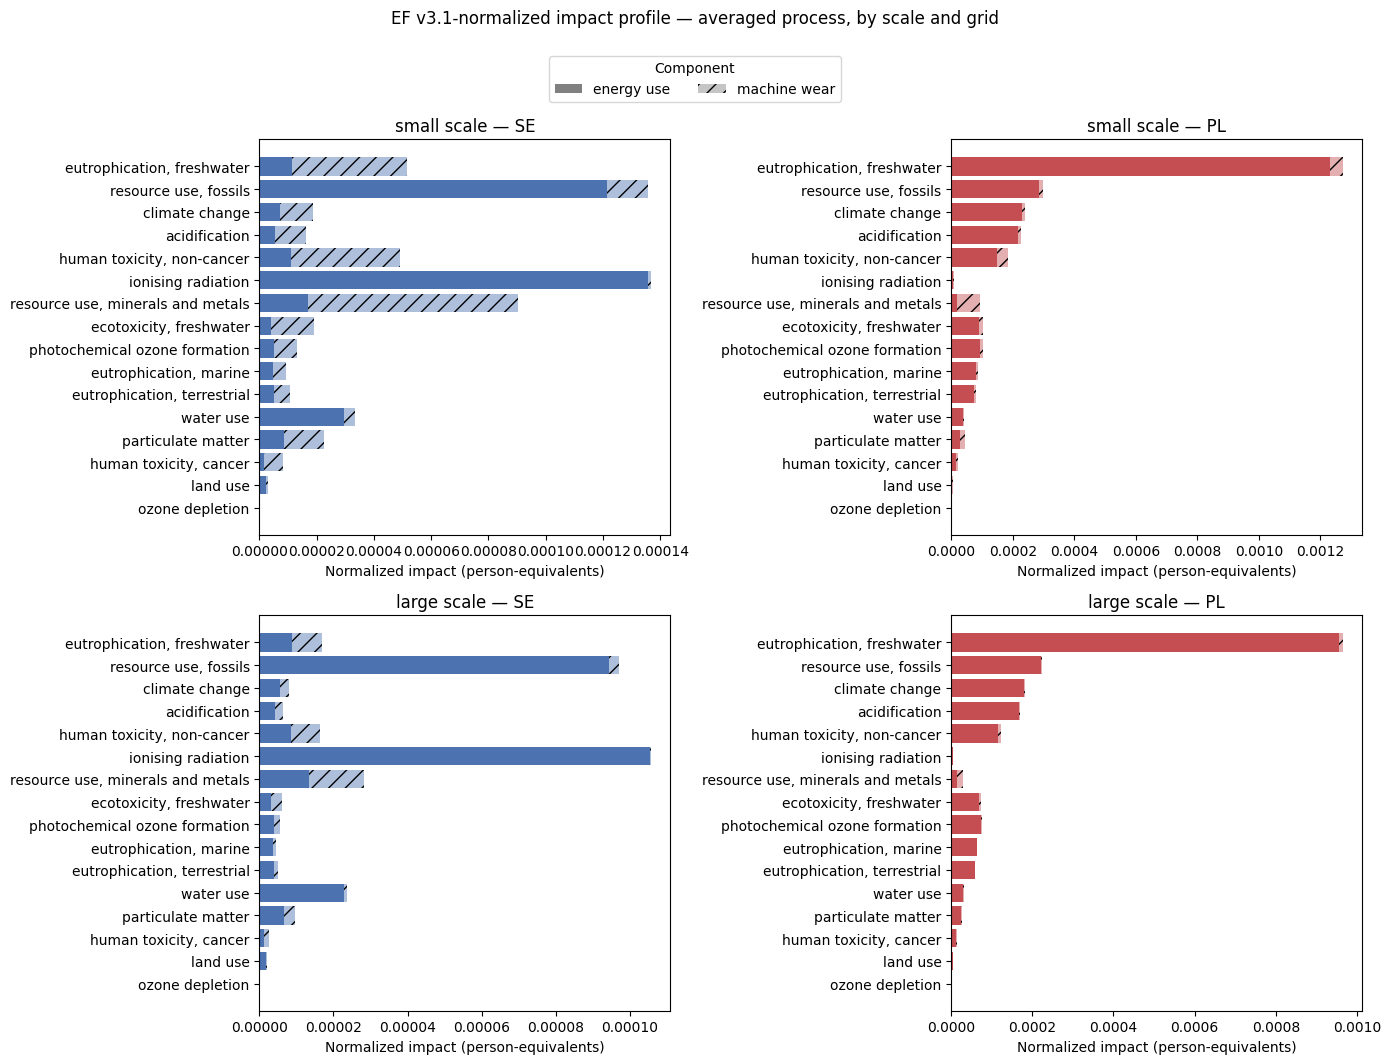

In [39]:
COUNTRY_COLORS = {"SE": "#4C72B0", "PL": "#C44E52"}
SCALES = ["small", "large"]

fig, axes = plt.subplots(len(SCALES), len(NORM_LOCATIONS), figsize=(14, 10), sharex=False)

for i, scale in enumerate(SCALES):
    for j, loc in enumerate(NORM_LOCATIONS):
        ax = axes[i, j]
        df_panel = (
            df_normalized[(df_normalized["scale"] == scale) & (df_normalized["location"] == loc)]
            .set_index("category")
            .reindex(category_order[::-1])  # reversed so highest-impact ends up at top of barh
        )
        color = COUNTRY_COLORS[loc]

        ax.barh(df_panel.index, df_panel["energy_use_normalized"], color=color)
        ax.barh(
            df_panel.index, df_panel["machine_wear_normalized"],
            left=df_panel["energy_use_normalized"],
            color=color, alpha=0.45, hatch="//",
        )
        ax.set_title(f"{scale} scale — {loc}")
        ax.set_xlabel("Normalized impact (person-equivalents)")

component_handles = [
    Patch(facecolor="grey", alpha=1.0, label="energy use"),
    Patch(facecolor="grey", alpha=0.45, hatch="//", label="machine wear"),
]
fig.legend(handles=component_handles, title="Component", loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("EF v3.1-normalized impact profile — averaged process, by scale and grid", y=1.06)
plt.tight_layout()
plt.show()

### 5.5 Sensitivity analysis — tornado diagrams

For each of three impact categories, this varies one parameter at a time from a
single baseline job (average of the small-scale and large-scale averages from
Section 5.4), holding everything else fixed, and plots the resulting range of
impact as a tornado diagram — parameters sorted top-to-bottom by how much they move
the result.

Continuous parameters (machine lifetime, machine weight, output, power) are swept
±50% around baseline. `electricity_location` is swept across its *actual* full
range — the lowest- and highest-impact country resolved in Section 2.4 — since a
symmetric percentage doesn't mean anything for a categorical parameter.

The baseline electricity location for the continuous-parameter sweeps is fixed at
`NL`, purely as a neutral anchor point — change `BASELINE_LOCATION` below if you'd
rather anchor somewhere else.

In [49]:
# ── Baseline job: global average = mean of the small-scale and large-scale averages ──
BASELINE_LOCATION = "NL"  # anchor point for the continuous-parameter sweeps

baseline_row = avg_params[
    ["machine_lifetime_hrs", "machine_weight_kg", "output_efficiency_kg_per_hr", "power_kW"]
].mean()
baseline_process_time_hrs = 1.0
baseline_kg_output = baseline_row["output_efficiency_kg_per_hr"] * baseline_process_time_hrs

BASELINE = dict(
    kg_machine=baseline_row["machine_weight_kg"],
    power_kW=baseline_row["power_kW"],
    process_time_hrs=baseline_process_time_hrs,
    machine_lifetime_hrs=baseline_row["machine_lifetime_hrs"],
    kg_output=baseline_kg_output,
    electricity_location=BASELINE_LOCATION,
)
print("Baseline job (global average):")
for k, v in BASELINE.items():
    print(f"  {k}: {v}")

# ── Metrics to evaluate, mapped to their bw2 category via canonical_to_bw2 ────
SENSITIVITY_CATEGORIES = {
    "Climate change": canonical_to_bw2["climate change"],
    "Resource use, minerals and metals": canonical_to_bw2["resource use, minerals and metals"],
    "Eutrophication, freshwater": canonical_to_bw2["eutrophication, freshwater"],
}

# ── Parameter ranges: actual min/max observed across all 8 process×scale rows ──
# (rather than an arbitrary ±% around baseline)
PARAM_RANGES = {
    "machine_lifetime_hrs": (
        df_process_params["machine_lifetime_hrs"].min(),
        df_process_params["machine_lifetime_hrs"].max(),
    ),
    "kg_machine": (
        df_process_params["machine_weight_kg"].min(),
        df_process_params["machine_weight_kg"].max(),
    ),
    "kg_output": (
        df_process_params["output_efficiency_kg_per_hr"].min() * BASELINE["process_time_hrs"],
        df_process_params["output_efficiency_kg_per_hr"].max() * BASELINE["process_time_hrs"],
    ),
    "power_kW": (
        df_process_params["power_kW"].min(),
        df_process_params["power_kW"].max(),
    ),
}

PARAM_DISPLAY_NAMES = {
    "machine_lifetime_hrs": "Machine lifetime",
    "kg_machine":           "Machine weight",
    "kg_output":            "Output",
    "power_kW":             "Power",
}


def get_impact(overrides, category):
    """Impact for `category`, from BASELINE with `overrides` applied."""
    params = {**BASELINE, **overrides}
    result = estimate_process_impact(**params)
    return result.total[category]


sensitivity_rows = []
for metric_name, bw2_category in SENSITIVITY_CATEGORIES.items():
    baseline_impact = get_impact({}, bw2_category)

    def pct_change(impact):
        return (impact - baseline_impact) / baseline_impact * 100

    # ── Continuous parameters: observed min–max across all processes/scales ────
    for param, (low_val, high_val) in PARAM_RANGES.items():
        low_impact = get_impact({param: low_val}, bw2_category)
        high_impact = get_impact({param: high_val}, bw2_category)
        sensitivity_rows.append({
            "metric": metric_name,
            "parameter": f"{PARAM_DISPLAY_NAMES[param]} ({low_val:,.2g}–{high_val:,.2g})",
            "low_impact": min(low_impact, high_impact),
            "high_impact": max(low_impact, high_impact),
            "low_pct": min(pct_change(low_impact), pct_change(high_impact)),
            "high_pct": max(pct_change(low_impact), pct_change(high_impact)),
            "baseline_impact": baseline_impact,
        })

    # ── Location: full resolved range (unchanged) ──────────────────────────────
    location_impacts = {
        loc: get_impact({"electricity_location": loc}, bw2_category)
        for loc in df_electricity_unit_burdens.columns
    }
    min_loc = min(location_impacts, key=location_impacts.get)
    max_loc = max(location_impacts, key=location_impacts.get)
    sensitivity_rows.append({
        "metric": metric_name,
        "parameter": f"Electricity location ({min_loc}–{max_loc})",
        "low_impact": location_impacts[min_loc],
        "high_impact": location_impacts[max_loc],
        "low_pct": pct_change(location_impacts[min_loc]),
        "high_pct": pct_change(location_impacts[max_loc]),
        "baseline_impact": baseline_impact,
    })

df_sensitivity = pd.DataFrame(sensitivity_rows)
df_sensitivity["range_pct"] = df_sensitivity["high_pct"] - df_sensitivity["low_pct"]
df_sensitivity.sort_values(["metric", "range_pct"], ascending=[True, False])


Baseline job (global average):
  kg_machine: 1713.125
  power_kW: 6.7125
  process_time_hrs: 1.0
  machine_lifetime_hrs: 31250.0
  kg_output: 4.75
  electricity_location: NL


,metric,parameter,low_impact,high_impact,low_pct,high_pct,baseline_impact,range_pct
2,Climate change,Output (0.05–15),2.033963e-01,61.018893,-68.333333,9400.000000,0.642304,9468.333333
3,Climate change,Power (0.1–25),3.834674e-02,2.312606,-94.029815,260.048431,0.642304,354.078247
4,Climate change,Electricity location (CH–CY),6.019910e-02,1.582756,-90.627632,146.418489,0.642304,237.046122
0,Climate change,Machine lifetime (6e+03–7e+04),6.261326e-01,0.765243,-2.517744,19.140272,0.642304,21.658017
1,Climate change,Machine weight (15–5e+03),6.133468e-01,0.698354,-4.508360,8.726340,0.642304,13.234700
12,"Eutrophication, freshwater",Output (0.05–15),9.145440e-05,0.027436,-68.333333,9400.000000,0.000289,9468.333333
14,"Eutrophication, freshwater",Electricity location (SE–BG),3.640902e-05,0.001871,-87.393145,547.952579,0.000289,635.345724
13,"Eutrophication, freshwater",Power (0.1–25),2.616049e-05,0.001015,-90.941764,251.508131,0.000289,342.449895
10,"Eutrophication, freshwater",Machine lifetime (6e+03–7e+04),2.765204e-04,0.000382,-4.253053,32.332351,0.000289,36.585404
11,"Eutrophication, freshwater",Machine weight (15–5e+03),2.668091e-04,0.000331,-7.615664,14.740808,0.000289,22.356471


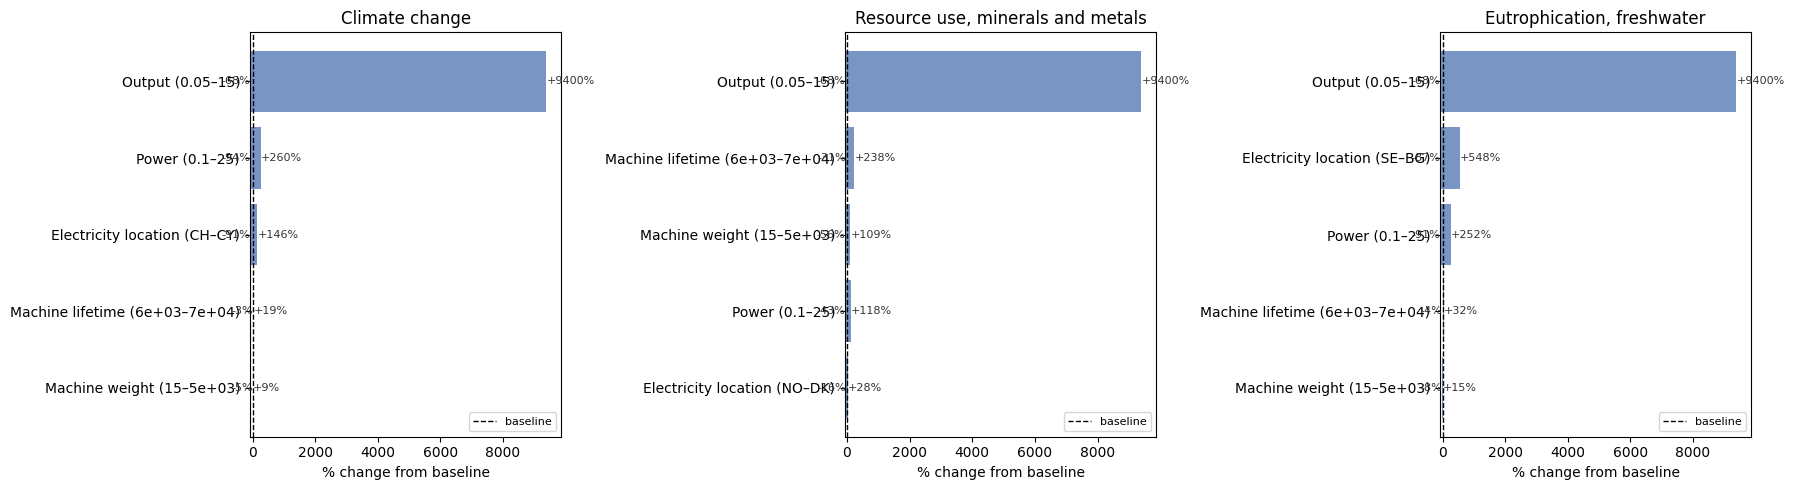

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric_name, _) in zip(axes, SENSITIVITY_CATEGORIES.items()):
    df_metric = (
        df_sensitivity[df_sensitivity["metric"] == metric_name]
        .sort_values("range_pct")  # ascending, so largest range ends up at top of barh
    )

    ax.barh(
        df_metric["parameter"], df_metric["high_pct"] - df_metric["low_pct"],
        left=df_metric["low_pct"], color="#4C72B0", alpha=0.75,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1, label="baseline")

    # ── Label each bar's low/high % directly ──────────────────────────────────
    for y, (low, high) in enumerate(zip(df_metric["low_pct"], df_metric["high_pct"])):
        ax.text(low, y, f"{low:+.0f}%", va="center", ha="right", fontsize=8, color="#333")
        ax.text(high, y, f"{high:+.0f}%", va="center", ha="left", fontsize=8, color="#333")

    ax.set_title(metric_name)
    ax.set_xlabel("% change from baseline")
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

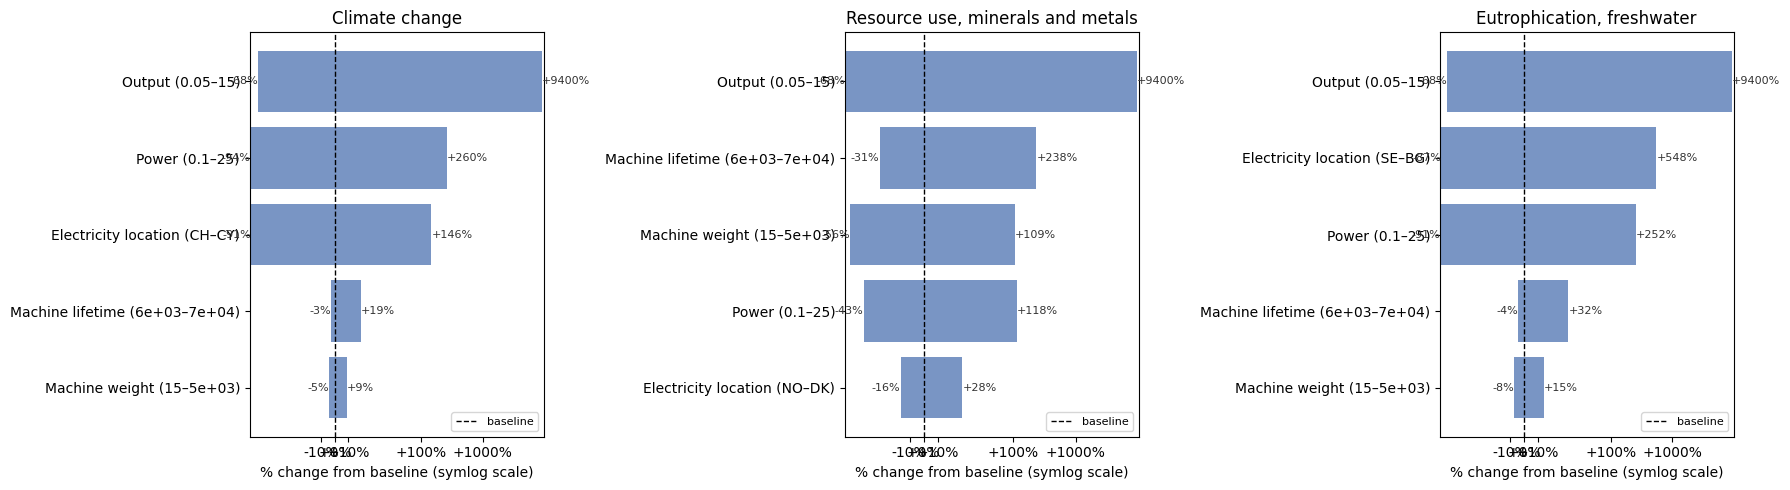

In [51]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric_name, _) in zip(axes, SENSITIVITY_CATEGORIES.items()):
    df_metric = (
        df_sensitivity[df_sensitivity["metric"] == metric_name]
        .sort_values("range_pct")
    )

    ax.barh(
        df_metric["parameter"], df_metric["high_pct"] - df_metric["low_pct"],
        left=df_metric["low_pct"], color="#4C72B0", alpha=0.75,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1, label="baseline")

    for y, (low, high) in enumerate(zip(df_metric["low_pct"], df_metric["high_pct"])):
        ax.text(low, y, f"{low:+.0f}%", va="center", ha="right", fontsize=8, color="#333")
        ax.text(high, y, f"{high:+.0f}%", va="center", ha="left", fontsize=8, color="#333")

    # ── Symlog x-axis: linear within ±50%, log beyond — keeps small bars
    # (e.g. machine weight at +9%) visible alongside huge ones (output at +9400%).
    ax.set_xscale("symlog", linthresh=50)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%"))

    ax.set_title(metric_name)
    ax.set_xlabel("% change from baseline (symlog scale)")
    ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()